Media pentru fiecare coloană:
et1_cond1_true     68.739837
et1_cond1_false     0.261969
et1_cond2_true     78.351400
et1_cond2_false     0.289070
et2_true           94.593496
et2_false           1.156278
et3_true           94.634146
et3_false           1.156278
et4_true           92.371274
et4_false           7.628726
final_distance     53.926524
dtype: float64

Mediana pentru fiecare coloană:
et1_cond1_true      76.666667
et1_cond1_false      0.000000
et1_cond2_true      85.555556
et1_cond2_false      0.000000
et2_true           100.000000
et2_false            0.000000
et3_true           100.000000
et3_false            0.000000
et4_true           100.000000
et4_false            0.000000
final_distance       0.000000
dtype: float64

Numărul de valori = 100.0 pentru fiecare coloană:
et1_cond1_true     13
et1_cond1_false     0
et1_cond2_true     16
et1_cond2_false     0
et2_true           71
et2_false           0
et3_true           73
et3_false           0
et4_true           86
et4_false

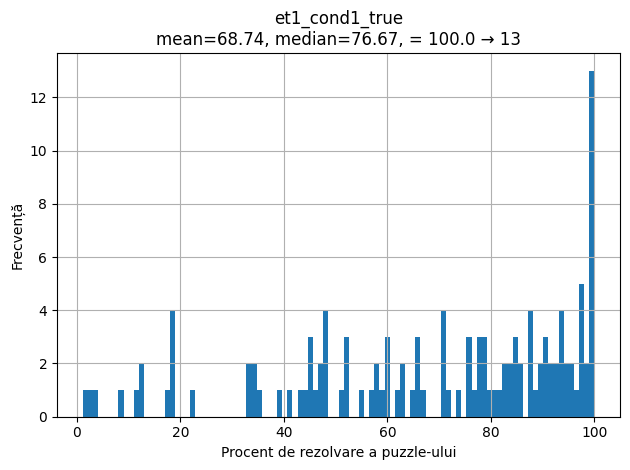

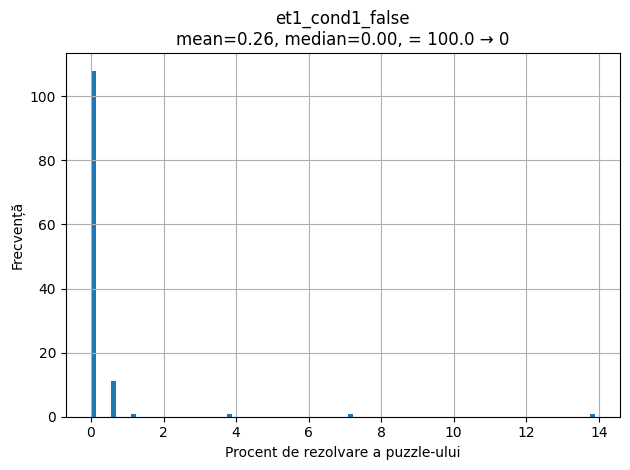

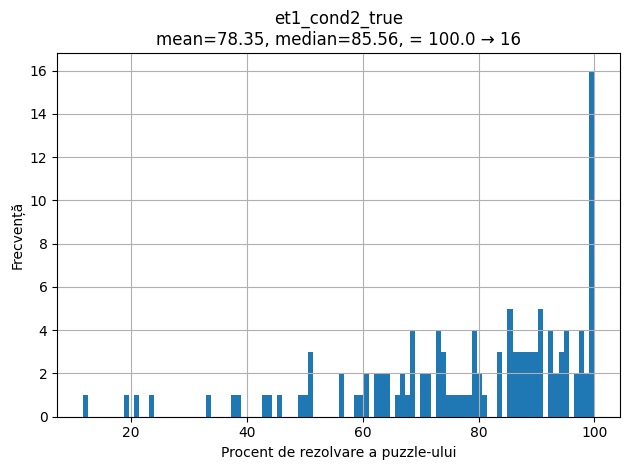

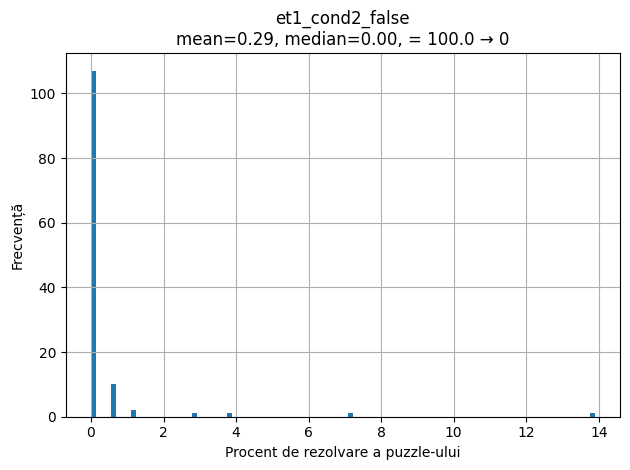

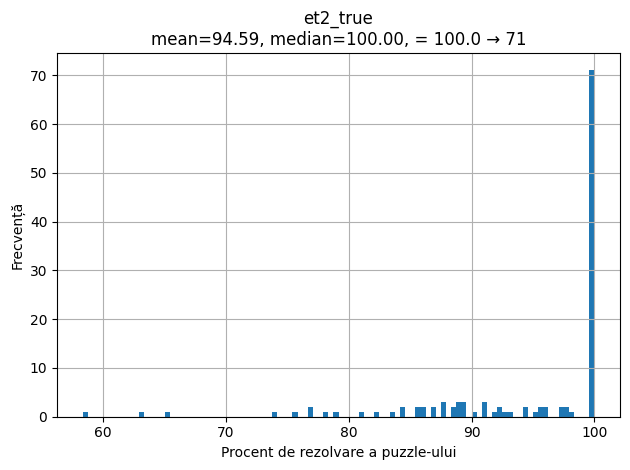

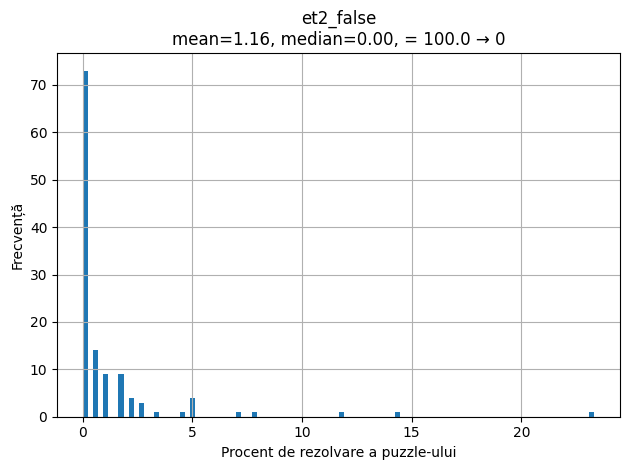

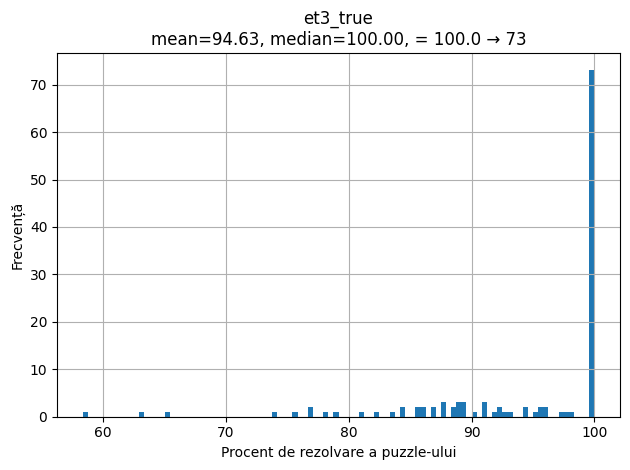

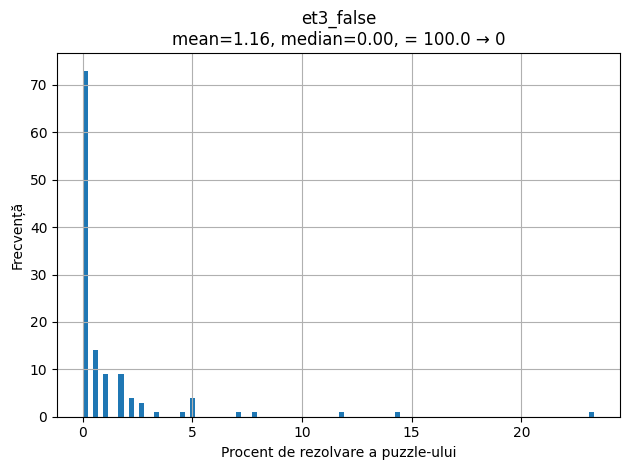

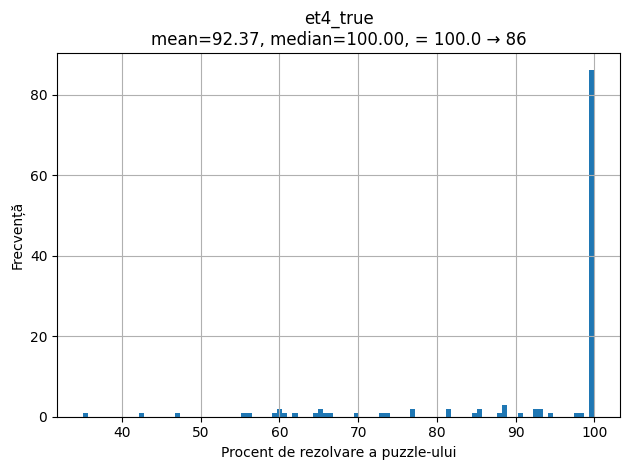

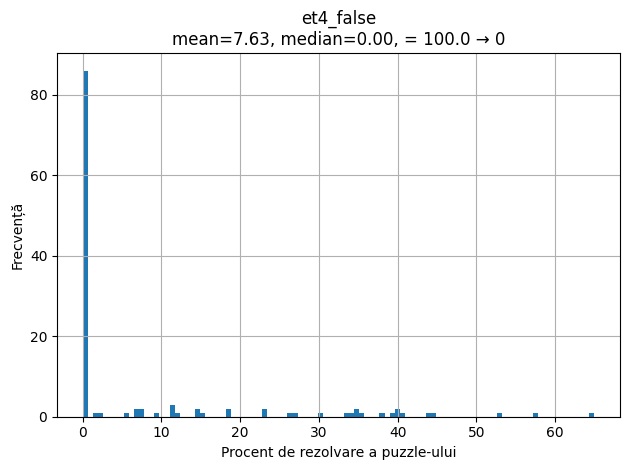

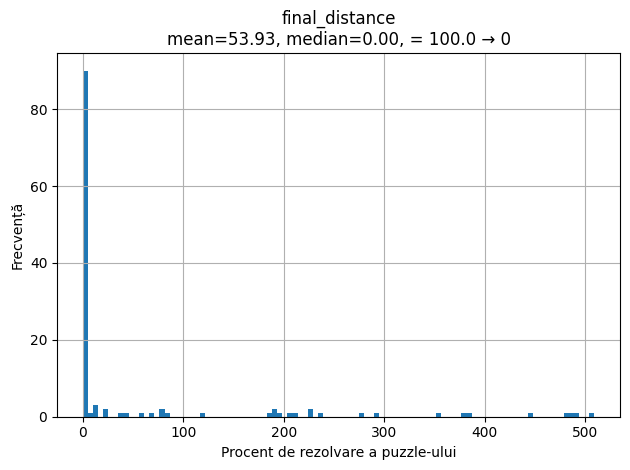

Media pentru fiecare coloană numerică:
                      mean      median  count = 100.0
et1_cond1_true   68.739837   76.666667             13
et1_cond1_false   0.261969    0.000000              0
et1_cond2_true   78.351400   85.555556             16
et1_cond2_false   0.289070    0.000000              0
et2_true         94.593496  100.000000             71
et2_false         1.156278    0.000000              0
et3_true         94.634146  100.000000             73
et3_false         1.156278    0.000000              0
et4_true         92.371274  100.000000             86
et4_false         7.628726    0.000000              0
final_distance   53.926524    0.000000              0


In [2]:
import pandas as pd
from pathlib import Path
import csv
import matplotlib.pyplot as plt


def complete_scv(input_path, output_path):
    with open(input_path, newline='') as infile, open(output_path, mode='w', newline='') as outfile:
        reader = csv.reader(infile)
        writer = csv.writer(outfile)

        for row in reader:
            if not row or row[0].strip().lower() == 'filename':
                writer.writerow(row)
                continue

            filename = row[0]
            *values, final_distance = row[1:]  

            pairs = [values[i:i+2] for i in range(0, len(values), 2)]
            last_valid = None
            for pair in pairs:
                if len(pair) == 2 and pair[0].strip() != "" and pair[1].strip() != "":
                    last_valid = pair

            completed_pairs = []
            for pair in pairs:
                if len(pair) == 2 and pair[0].strip() != "" and pair[1].strip() != "":
                    completed_pairs.extend(pair)
                elif last_valid:
                    completed_pairs.extend(last_valid)
                else:
                    completed_pairs.extend(["", ""])

            writer.writerow([filename] + completed_pairs + [final_distance])

complete_scv("new_statistics/results_20.csv", "new_statistics/complete_results_20.csv")

def analyze_csv(csv_path, threshold=100.0):
    df = pd.read_csv(csv_path)
    numeric_df = df.iloc[:, 1:]

    numeric_df = numeric_df.apply(pd.to_numeric)
    column_means   = numeric_df.mean()
    column_medians = numeric_df.median()
    counts_below_threshold = (numeric_df == threshold).sum()

    print("Media pentru fiecare coloană:")
    print(column_means, end="\n\n")
    print("Mediana pentru fiecare coloană:")
    print(column_medians, end="\n\n")
    print(f"Numărul de valori = {threshold} pentru fiecare coloană:")
    print(counts_below_threshold, end="\n\n")

    for col in numeric_df.columns:
        plt.figure()
        numeric_df[col].dropna().hist(bins=100)
        plt.title(f"{col}\nmean={column_means[col]:.2f}, median={column_medians[col]:.2f}, = {threshold} → {counts_below_threshold[col]}")
        plt.xlabel("Procent de rezolvare a puzzle-ului")
        plt.ylabel("Frecvență")
        plt.grid(True)
        plt.tight_layout()

    plt.show()

    summary = pd.DataFrame({
        'mean':   column_means,
        'median': column_medians,
        f'count = {threshold}': counts_below_threshold
    })
    return summary


csv_completat = "new_statistics/complete_results_10.csv"
medii = analyze_csv(csv_completat)
print("Media pentru fiecare coloană numerică:")
print(medii)



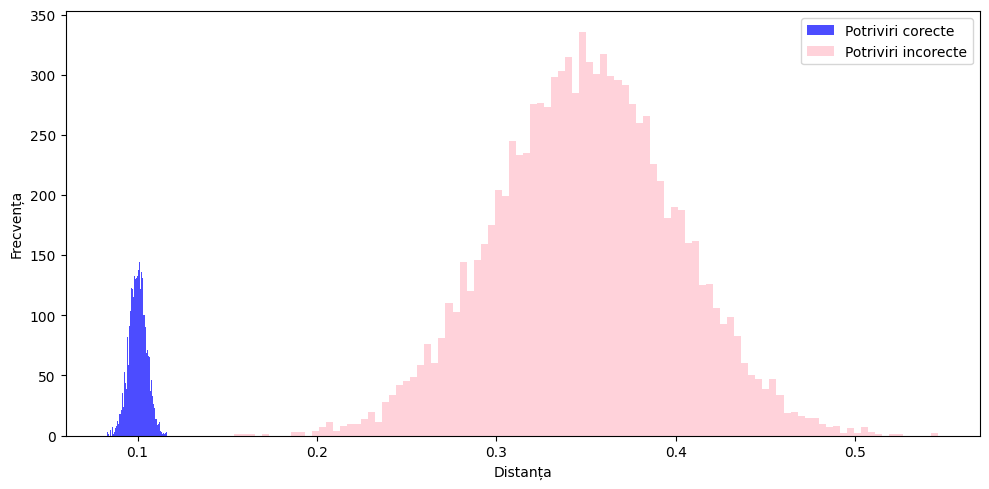

In [3]:
import numpy as np
np.random.seed(42)
zoom_correct = np.random.normal(loc=0.35, scale=0.05, size=10000)

zoom_incorrect = np.random.normal(loc=0.1, scale=0.005, size=5000)

# Plot
plt.figure(figsize=(10, 5))
plt.hist(zoom_incorrect, bins=100, alpha=0.7, color='blue', label='Potriviri corecte')
plt.hist(zoom_correct, bins=100, alpha=0.7, color='pink', label='Potriviri incorecte')

plt.xlabel("Distanța")
plt.ylabel("Frecvența")
plt.legend()
plt.tight_layout()
plt.show()